<h2>Term Deposit Marketing</h2>

**Project Overview**

**Background:**

We are a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.

We are interested in developing a robust machine learning system that leverages information coming from call center data.

Ultimately, we are looking for ways to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.

**Data Description:**

The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

**Attributes:**

age : age of customer (numeric)

job : type of job (categorical)

marital : marital status (categorical)

education (categorical)

default: has credit in default? (binary)

balance: average yearly balance, in euros (numeric)

housing: has a housing loan? (binary)

loan: has personal loan? (binary)

contact: contact communication type (categorical)

day: last contact day of the month (numeric)

month: last contact month of year (categorical)

duration: last contact duration, in seconds (numeric)

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

Output (desired target):

y - has the client subscribed to a term deposit? (binary)

**Download Data:**

https://drive.google.com/file/d/1EW-XMnGfxn-qzGtGPa3v_C63Yqj2aGf7

**Goal(s):**

Predict if the customer will subscribe (yes/no) to a term deposit (variable y)

**Success Metric(s):**

Hit 81% or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

**Current Challenges:**

We are also interested in finding customers who are more likely to buy the investment product. Determine the segment(s) of customers our client should prioritize.

What makes the customers buy? Tell us which feature we should be focusing more on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Relevant Project Paths to locate raw_data:
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
print(f'Project root directory is:{PROJ_ROOT}')
print(f'Data directory is:{DATA_DIR}')
print(f'Raw data directory is:{RAW_DATA_DIR}')

raw_data_file_name = 'term-deposit-marketing-2020.csv'
RAW_DATA_PATH = RAW_DATA_DIR / raw_data_file_name
print(f'Raw data path is:{RAW_DATA_PATH}')


Project root directory is:C:\Users\cochr\Data Science Projects\lA82lBNDpo9AlAnK
Data directory is:C:\Users\cochr\Data Science Projects\lA82lBNDpo9AlAnK\data
Raw data directory is:C:\Users\cochr\Data Science Projects\lA82lBNDpo9AlAnK\data\raw
Raw data path is:C:\Users\cochr\Data Science Projects\lA82lBNDpo9AlAnK\data\raw\term-deposit-marketing-2020.csv


<h3>Data Loading and Missing/Null Value Assessment

In [3]:
raw_data = pd.read_csv(RAW_DATA_PATH)
raw_data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [5]:
print("Missing values per column:")
print(raw_data.isnull().sum())

unknown_counts = (raw_data == 'unknown').sum()
print("\n'Unknown' values per column:")
print(f"\n{unknown_counts}")

print("\nTotal missing values (including 'unknown'):")
total_missing = raw_data.isnull().sum() + (raw_data == 'unknown').sum()
print(total_missing[total_missing > 0])

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

'Unknown' values per column:

age              0
job            235
marital          0
education     1531
default          0
balance          0
housing          0
loan             0
contact      12765
day              0
month            0
duration         0
campaign         0
y                0
dtype: int64

Total missing values (including 'unknown'):
job            235
education     1531
contact      12765
dtype: int64


Whilst there are no 'null' or 'NaN' values here, there are plenty of 'unknown' values which we need to treat as being empty and therefore requiring imputation/deletion. It's important to carry this kind of thing out on training data (not test data, yet). Develop the imputation strategy, then apply to the test data...

A helpful guide to imputation: https://www.analyticsvidhya.com/blog/2021/10/handling-missing-value/

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# Separate features and target
X = raw_data.drop(columns='y')
y = raw_data['y']

# Train-test split, with stratify='y' to capture the class imbalance of 'y'.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.3,random_state=13,stratify=y)

- For 'job' and 'education', <5% of rows contain 'unknown'. May be best to delete these rows or use a mode imputation.
- There are >25% rows containing 'unknown' for 'contact'. May need to use a KNN,model, or grouped mode (even better, grouped mode fallback levels) based imputation strategy.
- KNN and model based strategies add lots of complexity, mode may add lots of class imbalance in the column. A grouped mode strategy may work well...

Grouped mode imputer:

In [8]:
def clean_and_impute_contact(X, y, unknown_value="unknown"):
    """
    Remove rows with unknown/missing job or education, then impute unknown/missing
    contact using grouped mode based on job and education.

    Imputation hierarchy:
    1. mode(contact) by job + education
    2. mode(contact) by job
    3. mode(contact) by education
    4. global mode(contact)

    Returns
    -------
    X_clean, y_clean
    """

    X = X.copy()
    y = y.copy()

    # Ensure y is a Series
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("y must be a Series or a single-column DataFrame.")
        y = y.iloc[:, 0]

    # Check index alignment before concat
    shared_index = X.index.intersection(y.index)

    if len(shared_index) == 0:
        raise ValueError(
            "X and y have no overlapping index values. "
            "This is why concat(join='inner') returns an empty dataframe. "
            "Reset both indexes or align them before calling this function."
        )

    target_col = y.name if y.name is not None else "__target__"

    # Avoid target name collision
    if target_col in X.columns:
        target_col = "__target__"

    data = pd.concat(
        [X, y.rename(target_col)],
        axis=1,
        join="inner"
    )

    if data.empty:
        raise ValueError("Data is empty after concatenating X and y.")

    required_cols = ["job", "education", "contact"]

    missing_cols = [col for col in required_cols if col not in data.columns]

    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    # Treat both "unknown" and NaN as missing
    for col in ["job", "education", "contact"]:
        data[col] = data[col].replace(unknown_value, np.nan)

    # Remove rows where job or education is missing
    data = data.dropna(subset=["job", "education"]).copy()

    if data.empty:
        raise ValueError(
            "Data is empty after dropping rows with missing job or education. "
            "Check how many rows contain unknown/NaN in these columns."
        )

    def first_mode(s):
        m = s.dropna().mode()
        return m.iloc[0] if not m.empty else np.nan

    known_contact = data.dropna(subset=["contact"]).copy()

    if known_contact.empty:
        raise ValueError(
            "No known contact values are available to learn imputation rules from."
        )

    # 1. Grouped mode by job + education
    group_mode = (
        known_contact
        .groupby(["job", "education"])["contact"]
        .agg(first_mode)
    )

    # 2. Fallback by job
    job_mode = (
        known_contact
        .groupby("job")["contact"]
        .agg(first_mode)
    )

    # 3. Fallback by education
    edu_mode = (
        known_contact
        .groupby("education")["contact"]
        .agg(first_mode)
    )

    # 4. Global fallback
    global_mode = first_mode(known_contact["contact"])

    unknown_mask = data["contact"].isna()

    if unknown_mask.any():

        keys = pd.Series(
            list(zip(
                data.loc[unknown_mask, "job"],
                data.loc[unknown_mask, "education"]
            )),
            index=data.loc[unknown_mask].index
        )

        imputed = keys.map(group_mode)

        # Fallback 1: job mode
        na_idx = imputed[imputed.isna()].index
        if len(na_idx) > 0:
            imputed.loc[na_idx] = data.loc[na_idx, "job"].map(job_mode)

        # Fallback 2: education mode
        na_idx = imputed[imputed.isna()].index
        if len(na_idx) > 0:
            imputed.loc[na_idx] = data.loc[na_idx, "education"].map(edu_mode)

        # Fallback 3: global mode
        imputed = imputed.fillna(global_mode)

        data.loc[unknown_mask, "contact"] = imputed

    X_clean = data.drop(columns=[target_col])
    y_clean = data[target_col]

    if y.name is not None:
        y_clean = y_clean.rename(y.name)

    return X_clean, y_clean

In [9]:
X_train_clean, y_train_clean = clean_and_impute_contact(X_train_raw,y_train_raw)
X_train_clean.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign
31488,41,blue-collar,married,secondary,no,0,yes,no,cellular,1,apr,625,2
11946,42,management,single,tertiary,no,-56,yes,no,cellular,20,jun,126,14
14355,32,technician,married,tertiary,no,240,yes,yes,cellular,14,jul,86,3
39108,24,blue-collar,single,secondary,no,-287,yes,no,cellular,18,may,504,1
25294,54,blue-collar,married,secondary,no,1070,no,no,cellular,18,nov,373,4


In [10]:
y_train_clean

31488    no
11946    no
14355    no
39108    no
25294    no
         ..
30422    no
37138    no
6738     no
37763    no
24330    no
Name: y, Length: 26811, dtype: str

In [11]:
# Check 'unknown' values in X_train_raw
print("=" * 60)
print("X_train_raw - 'Unknown' Assessment")
print("=" * 60)
unknown_counts_train_raw = (X_train_raw == 'unknown').sum()
unknown_rate_train_raw = (unknown_counts_train_raw / len(X_train_raw) * 100).round(2)
print("\n'Unknown' values:")
filtered = unknown_counts_train_raw[unknown_counts_train_raw > 0]
print(filtered if not filtered.empty else "None")
print("\n'Unknown' rate (%):")
filtered_rate = unknown_rate_train_raw[unknown_rate_train_raw > 0]
print(filtered_rate if not filtered_rate.empty else "None")

# Check 'unknown' values in X_train_clean
print("=" * 60)
print("X_train_clean - 'Unknown' Assessment")
print("=" * 60)
unknown_counts_train_clean = (X_train_clean == 'unknown').sum()
unknown_rate_train_clean = (unknown_counts_train_clean / len(X_train_clean) * 100).round(2)
print("\n'Unknown' values:")
filtered = unknown_counts_train_clean[unknown_counts_train_clean > 0]
print(filtered if not filtered.empty else "None - imputation successful!")
print("\n'Unknown' rate (%):")
filtered_rate = unknown_rate_train_clean[unknown_rate_train_clean > 0]
print(filtered_rate if not filtered_rate.empty else "None - imputation successful!")


X_train_raw - 'Unknown' Assessment

'Unknown' values:
job           161
education    1104
contact      8968
dtype: int64

'Unknown' rate (%):
job           0.57
education     3.94
contact      32.03
dtype: float64
X_train_clean - 'Unknown' Assessment

'Unknown' values:
None - imputation successful!

'Unknown' rate (%):
None - imputation successful!


In [12]:
X_train_raw.shape

(28000, 13)

In [13]:
X_train_clean.shape

(26811, 13)

In [14]:
print(f"Rows removed from training set during imputation: {X_train_raw.shape[0]-X_train_clean.shape[0]}/{X_train_raw.shape[0]}")

Rows removed from training set during imputation: 1189/28000


<h3>Exploratory Data Analysis (EDA)

Make sure this is done on training data post-imputation (concatenation of X_train and y_train post imputation).

In [15]:
eda_data = pd.concat([X_train_clean.copy(), y_train_clean.copy()], axis=1, join="inner")
eda_data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
31488,41,blue-collar,married,secondary,no,0,yes,no,cellular,1,apr,625,2,no
11946,42,management,single,tertiary,no,-56,yes,no,cellular,20,jun,126,14,no
14355,32,technician,married,tertiary,no,240,yes,yes,cellular,14,jul,86,3,no
39108,24,blue-collar,single,secondary,no,-287,yes,no,cellular,18,may,504,1,no
25294,54,blue-collar,married,secondary,no,1070,no,no,cellular,18,nov,373,4,no


In [16]:
# Unique value diversity assessment for all columns except age, balance, campaign, and duration (these can be considered continuous):
exclude_cols = ['age', 'balance', 'duration','campaign']
categorical_cols = [col for col in eda_data.columns if col not in exclude_cols]

print("Unique value assessment: No. unique values per selected column")
for col in categorical_cols:
    print(f"{col}: {eda_data[col].nunique()}")

Unique value assessment: No. unique values per selected column
job: 11
marital: 3
education: 3
default: 2
housing: 2
loan: 2
contact: 2
day: 31
month: 11
y: 2


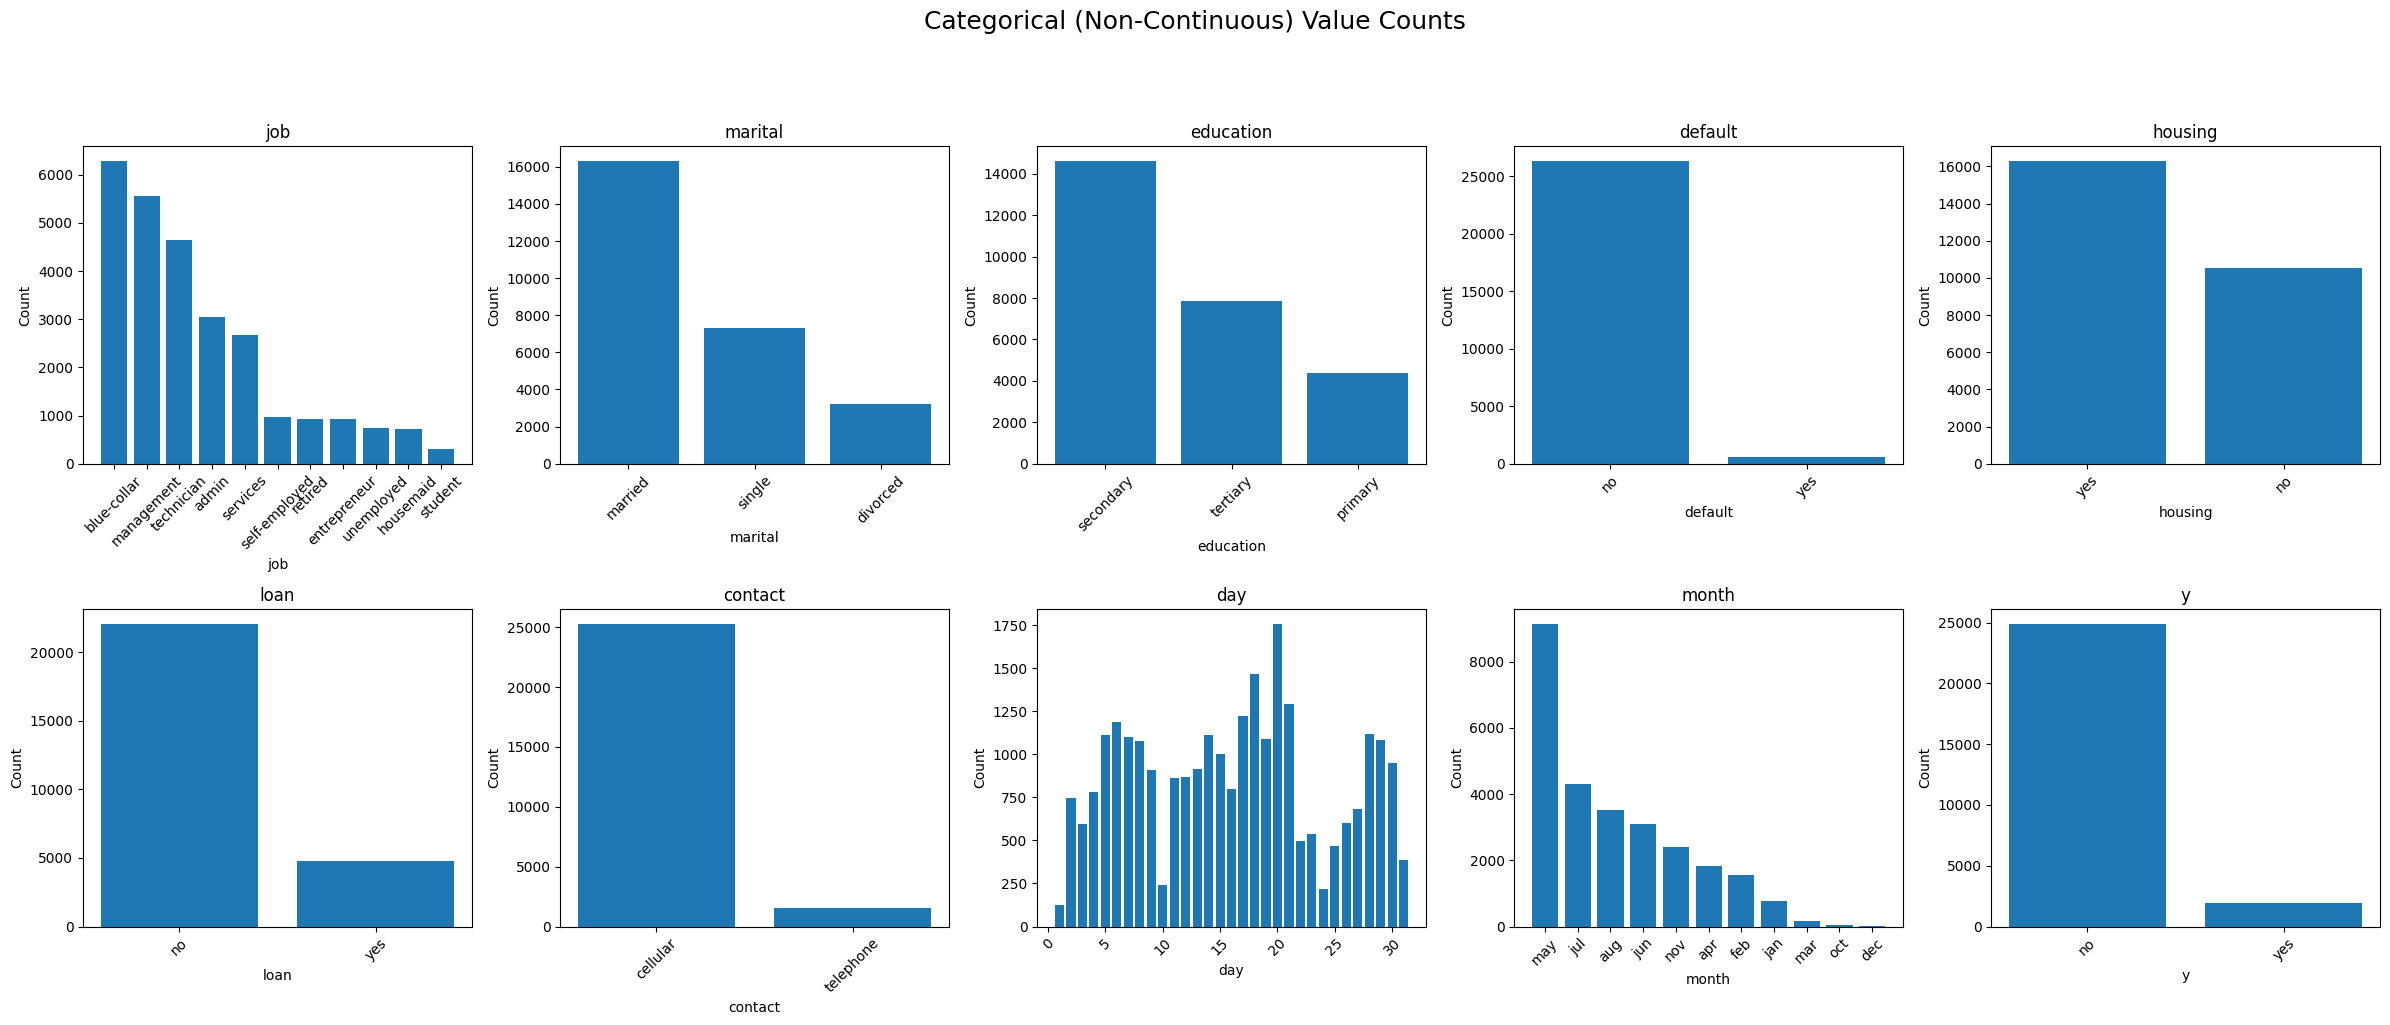

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = eda_data[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Categorical (Non-Continuous) Value Counts", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

- From the outset it is clear that that there is a massive class imbalance within the labels (y).
- There are lots of unique values within the 'categorical' features which may introduce high dimensionality during feature engineering if encoding is used.

In [18]:
eda_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='str')

In [19]:
# It seems like there is a large number of rows which have a 'month' = 'may', but the day feature looks fairly random.
# Is there a correlation between 'day' and 'y'?

pearson_cols = ['age', 'balance', 'duration','campaign','day','y']

# Encode target to numeric for correlation
y_numeric = eda_data['y'].map({'no': 0, 'yes': 1})

# Build a numeric-only frame for selected columns
pearson_df = eda_data[pearson_cols[:-1]].copy()
pearson_df['y'] = y_numeric

# Pearson correlation of each selected column with y
pearson_with_y = pearson_df.corr(method='pearson')['y'].drop('y')
print("Pearson correlation coefficients with y:")
print(pearson_with_y)

Pearson correlation coefficients with y:
age        -0.017729
balance     0.028334
duration    0.474193
campaign   -0.037770
day        -0.012481
Name: y, dtype: float64


In [20]:
# Encoding 'day' could be done ordinally but due to its cyclical nature, day 28-31 (depending on month) is only 1 day away from
# the day = 1, but the model with think the distance is 28-31.

# One-hot encoding will introduce 30 more features = High dimensionality.

# Frequency encoding = Different days may be encoded to give similar/identical frequency encoded values due to random nature
# of the 'day' distribution.

# It has a low correlation compared to the other 'numerical' columns. 
# I think it would be easier to remove this column all together. Other correlation metrics should be used to see if there is
# plausible evidence that the correlation between 'day' and 'y' is low enough to warrant removal. We can do this at the
# feature selection stage.

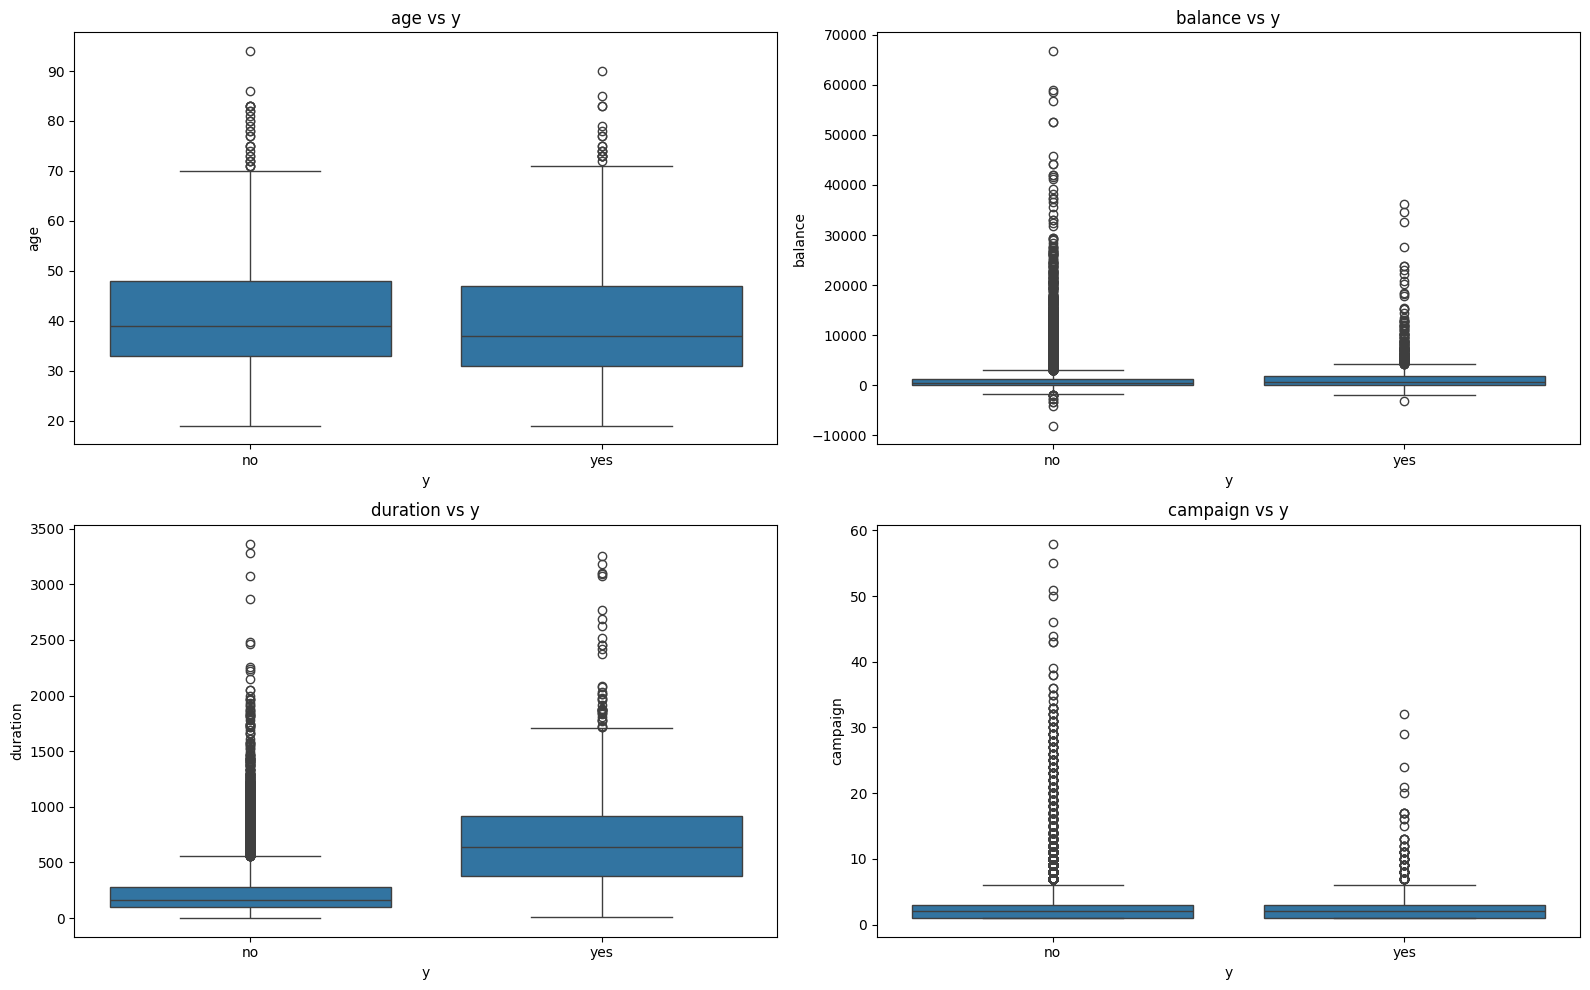

In [21]:
# Outlier detection via plotting of numeric columns vs y:

boxplot_cols = ['age', 'balance', 'duration','campaign','y']

num_cols = [col for col in boxplot_cols if col != 'y']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=eda_data, x='y', y=col, ax=ax)
    ax.set_title(f'{col} vs y')
    ax.set_xlabel('y')
    ax.set_ylabel(col)

for ax in axes[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

- There appears to be a large number of outliers when we plot boxplots vs target class value.
- Plotting without the target class value

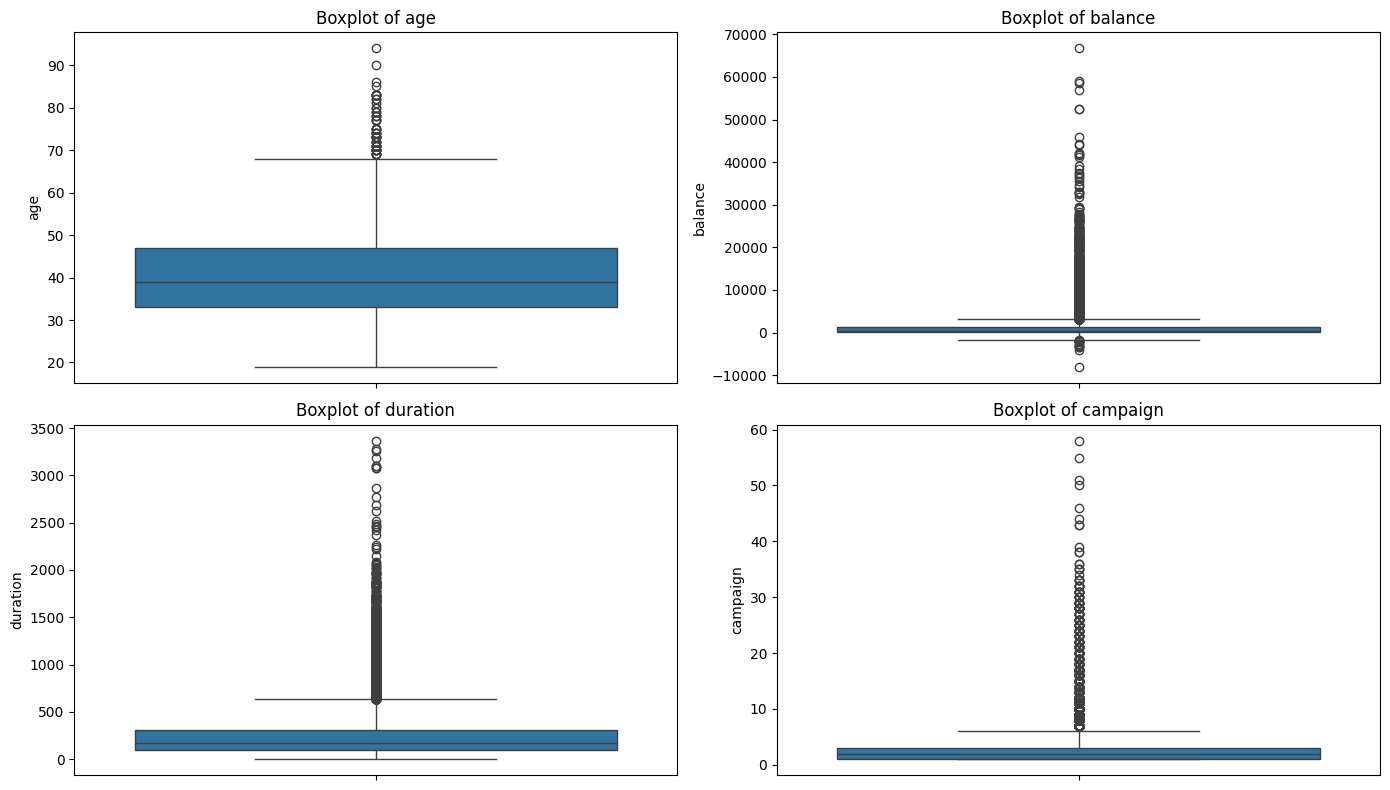

In [22]:
# Boxplots for numeric columns only (exclude target 'y')
num_cols = [c for c in boxplot_cols if c != 'y']

n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=eda_data[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)

# Hide any unused subplot axes
for ax in axes[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [23]:
import pickle

# Saving the split + imputed data in the 'data/interim' directory:

INTERIM_DATA_DIR = DATA_DIR / "interim"
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save train data (raw split)
with open(INTERIM_DATA_DIR / "X_train_raw.pkl", "wb") as f:
    pickle.dump(X_train_raw, f)

with open(INTERIM_DATA_DIR / "y_train_raw.pkl", "wb") as f:
    pickle.dump(y_train_raw, f)

# Save train data (post-imputation)
with open(INTERIM_DATA_DIR / "X_train_clean.pkl", "wb") as f:
    pickle.dump(X_train_clean, f)

with open(INTERIM_DATA_DIR / "y_train_clean.pkl", "wb") as f:
    pickle.dump(y_train_clean, f)

# Save test data (raw split, imputation to be applied later)
with open(INTERIM_DATA_DIR / "X_test_raw.pkl", "wb") as f:
    pickle.dump(X_test_raw, f)

with open(INTERIM_DATA_DIR / "y_test_raw.pkl", "wb") as f:
    pickle.dump(y_test_raw, f)
